In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Chargement
df = pd.read_csv("../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv")

# Séparation features / target
X = df.drop(columns=["Churn"])
y = df["Churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [95]:
print(X_train.shape)
print(X_test.shape)

(3497, 51)
(875, 51)


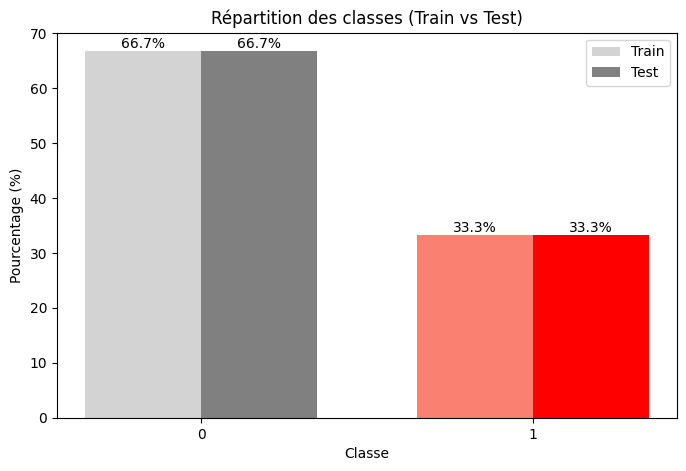

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Calcul des distributions (%)
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

# S'assurer que les classes sont dans le bon ordre (0, 1)
classes = [0, 1]
train_values = [train_dist.get(c, 0) for c in classes]
test_values = [test_dist.get(c, 0) for c in classes]

# Position des barres
x = np.arange(len(classes))
width = 0.35

# Création du plot
plt.figure(figsize=(8, 5))

# Train (gris clair / rouge clair)
plt.bar(x - width/2, train_values, width, label='Train',
        color=['lightgray', 'salmon'])

# Test (gris foncé / rouge foncé)
plt.bar(x + width/2, test_values, width, label='Test',
        color=['gray', 'red'])

# Labels
plt.xlabel("Classe")
plt.ylabel("Pourcentage (%)")
plt.title("Répartition des classes (Train vs Test)")
plt.xticks(x, classes)
plt.legend()

# Affichage des valeurs sur les barres
for i in range(len(classes)):
    plt.text(x[i] - width/2, train_values[i] + 0.5, f"{train_values[i]:.1f}%", ha='center')
    plt.text(x[i] + width/2, test_values[i] + 0.5, f"{test_values[i]:.1f}%", ha='center')

plt.show()

In [98]:
import re
import numpy as np
import pandas as pd
import ipaddress
from datetime import datetime


class Parseur:
    def __init__(
        self,
        registration_col="RegistrationDate",
        ip_col="LastLoginIP",
        drop_original_date=False,
        drop_original_ip=False
    ):
        self.registration_col = registration_col
        self.ip_col = ip_col
        self.drop_original_date = drop_original_date
        self.drop_original_ip = drop_original_ip
        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes par rapport au train : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires non vues au train : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    def _is_missing_text(self, x):
        if pd.isna(x):
            return True
        return str(x).strip().lower() in {
            "", "unknown", "inconnu", "na", "n/a", "none", "null", "missing", "?"
        }

    def _clean_text(self, x):
        if self._is_missing_text(x):
            return np.nan
        return str(x).strip()

    # ----------------------------------------------------------
    # RegistrationDate : uniformiser puis convertir
    # Formats gérés :
    # - dd/mm/yy
    # - dd/mm/yyyy
    # - yyyy-mm-dd
    # ----------------------------------------------------------
    def _standardize_registration_date_value(self, x):
        if self._is_missing_text(x):
            return np.nan

        s = str(x).strip()

        try:
            # yyyy-mm-dd
            if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
                dt = datetime.strptime(s, "%Y-%m-%d")
                return dt.strftime("%Y-%m-%d")

            # dd/mm/yyyy
            if re.fullmatch(r"\d{2}/\d{2}/\d{4}", s):
                dt = datetime.strptime(s, "%d/%m/%Y")
                return dt.strftime("%Y-%m-%d")

            # dd/mm/yy
            if re.fullmatch(r"\d{2}/\d{2}/\d{2}", s):
                dt = datetime.strptime(s, "%d/%m/%y")
                return dt.strftime("%Y-%m-%d")

            return np.nan

        except ValueError:
            return np.nan

    def _standardize_registration_date_series(self, s):
        return s.apply(self._standardize_registration_date_value)

    # ----------------------------------------------------------
    # Parsing LastLoginIP
    # ----------------------------------------------------------
    def _extract_ip_features(self, x):
        if self._is_missing_text(x):
            return pd.Series(
                {
                    "IsValidIP": np.nan,
                    "IsPrivateIP": np.nan,
                    "IPVersion": np.nan,
                }
            )

        s = str(x).strip()

        try:
            ip_obj = ipaddress.ip_address(s)
            return pd.Series(
                {
                    "IsValidIP": 1,
                    "IsPrivateIP": int(ip_obj.is_private),
                    "IPVersion": ip_obj.version,
                }
            )
        except ValueError:
            return pd.Series(
                {
                    "IsValidIP": 0,
                    "IsPrivateIP": np.nan,
                    "IPVersion": np.nan,
                }
            )

    # ----------------------------------------------------------
    # Fit
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        output_columns = self.input_columns_.copy()

        if self.registration_col in self.input_columns_:
            for col in ["RegYear", "RegMonth", "RegDay", "RegWeekday"]:
                if col not in output_columns:
                    output_columns.append(col)

            if self.drop_original_date and self.registration_col in output_columns:
                output_columns.remove(self.registration_col)

        if self.ip_col in self.input_columns_:
            for col in ["IsValidIP", "IsPrivateIP", "IPVersion"]:
                if col not in output_columns:
                    output_columns.append(col)

            if self.drop_original_ip and self.ip_col in output_columns:
                output_columns.remove(self.ip_col)

        self.output_columns_ = output_columns
        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # Transform
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le parseur doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = X[self.input_columns_].copy()

        # -------------------------
        # RegistrationDate
        # -------------------------
        if self.registration_col in X.columns:
            X[self.registration_col] = X[self.registration_col].apply(self._clean_text)

            # 1) Uniformiser en texte YYYY-MM-DD
            standardized_dates = self._standardize_registration_date_series(X[self.registration_col])

            # 2) Convertir en vrai datetime pandas
            X[self.registration_col] = pd.to_datetime(
                standardized_dates,
                format="%Y-%m-%d",
                errors="coerce"
            )

            # 3) Extraire les features
            X["RegYear"] = X[self.registration_col].dt.year
            X["RegMonth"] = X[self.registration_col].dt.month
            X["RegDay"] = X[self.registration_col].dt.day
            X["RegWeekday"] = X[self.registration_col].dt.weekday

        # -------------------------
        # LastLoginIP
        # -------------------------
        if self.ip_col in X.columns:
            X[self.ip_col] = X[self.ip_col].apply(self._clean_text)
            ip_features = X[self.ip_col].apply(self._extract_ip_features)
            X = pd.concat([X, ip_features], axis=1)

        # -------------------------
        # Drop éventuel des colonnes brutes
        # -------------------------
        if self.drop_original_date and self.registration_col in X.columns:
            X = X.drop(columns=[self.registration_col])

        if self.drop_original_ip and self.ip_col in X.columns:
            X = X.drop(columns=[self.ip_col])

        X = X[self.output_columns_].copy()
        return X

    # ----------------------------------------------------------
    # Fit transform
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [99]:
parseur = Parseur(
    registration_col="RegistrationDate",
    ip_col="LastLoginIP",
    drop_original_date=False,
    drop_original_ip=False
)



In [100]:
X_train_parsed = parseur.fit_transform(X_train)
X_test_parsed = parseur.transform(X_test)

In [101]:
print(X_train_parsed[["RegistrationDate", "RegYear", "RegMonth", "RegDay", "RegWeekday"]].head())
print(X_test_parsed[["RegistrationDate", "RegYear", "RegMonth", "RegDay", "RegWeekday"]].head())

     RegistrationDate  RegYear  RegMonth  RegDay  RegWeekday
380        2010-11-09   2010.0      11.0     9.0         1.0
2472       2011-05-25   2011.0       5.0    25.0         2.0
1961              NaT      NaN       NaN     NaN         NaN
2029       2011-03-19   2011.0       3.0    19.0         5.0
1384       2011-02-13   2011.0       2.0    13.0         6.0
     RegistrationDate  RegYear  RegMonth  RegDay  RegWeekday
4237       2011-12-07   2011.0      12.0     7.0         2.0
871        2010-03-21   2010.0       3.0    21.0         6.0
2629       2011-01-28   2011.0       1.0    28.0         4.0
1775              NaT      NaN       NaN     NaN         NaN
488        2010-10-11   2010.0      10.0    11.0         0.0


In [102]:
from sklearn.impute import KNNImputer


class RetailPreprocessor:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

        # Colonnes à supprimer
        self.columns_to_drop = [
            "CustomerID",
            "WeekendPreference",
            "NewsletterSubscribed"
        ]

        # Colonnes métier
        self.age_col = "Age"
        self.agecat_col = "AgeCategory"
        self.gender_col = "Gender"
        self.region_col = "Region"
        self.country_col = "Country"
        self.support_col = "SupportTicketsCount"
        self.satisfaction_col = "SatisfactionScore"
        self.avgdays_col = "AvgDaysBetweenPurchases"

        # Colonnes créées par Parseur : date
        self.date_feature_cols = [
            "RegYear",
            "RegMonth",
            "RegDay",
            "RegWeekday"
        ]

        # Colonnes créées par Parseur : IP
        self.ip_valid_col = "IsValidIP"
        self.ip_private_col = "IsPrivateIP"
        self.ip_version_col = "IPVersion"
        self.ip_feature_cols = [
            self.ip_valid_col,
            self.ip_private_col,
            self.ip_version_col
        ]

        # Variables les plus dépendantes pour KNN sur AvgDaysBetweenPurchases
        self.knn_num_features = [
            "Frequency",
            "CustomerTenureDays",
            "UniqueInvoices"
        ]

        self.text_missing_values = {
            "", "unknown", "inconnu", "na", "n/a", "none", "null",
            "missing", "?", "unspecified"
        }

        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes par rapport au train : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires non vues au train : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    def _is_text_missing(self, x):
        if pd.isna(x):
            return True
        return str(x).strip().lower() in self.text_missing_values

    def _clean_text(self, x):
        if self._is_text_missing(x):
            return np.nan
        return str(x).strip()

    def _mode_or_default(self, series, default=np.nan):
        s = series.dropna()
        if s.empty:
            return default
        return s.mode().iloc[0]

    def _safe_median(self, series, default=np.nan):
        s = pd.to_numeric(series, errors="coerce").dropna()
        if s.empty:
            return default
        return s.median()

    def _safe_discrete_median(self, series, default=np.nan):
        s = pd.to_numeric(series, errors="coerce").dropna()
        if s.empty:
            return default
        return int(round(s.median()))

    def _age_to_category(self, age):
        if pd.isna(age):
            return "Inconnu"

        age = float(age)

        if 18 <= age <= 24:
            return "18-24"
        elif 25 <= age <= 34:
            return "25-34"
        elif 35 <= age <= 44:
            return "35-44"
        elif 45 <= age <= 54:
            return "45-54"
        elif 55 <= age <= 64:
            return "55-64"
        elif age >= 65:
            return "65+"
        else:
            return "Inconnu"

    # ----------------------------------------------------------
    # Outliers : bornes IQR apprises sur train
    # Exclure les colonnes IP dérivées
    # ----------------------------------------------------------
    def _learn_outlier_bounds(self, X):
        self.outlier_bounds_ = {}

        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [
            c for c in numeric_cols
            if c not in self.columns_to_drop and c not in self.ip_feature_cols
        ]

        for col in numeric_cols:
            s = pd.to_numeric(X[col], errors="coerce").dropna()

            if s.empty or s.nunique() <= 1:
                continue

            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1

            if iqr == 0:
                continue

            lower_limit = q1 - 1.5 * iqr
            upper_limit = q3 + 1.5 * iqr

            self.outlier_bounds_[col] = (lower_limit, upper_limit)

    def _cap_outliers(self, X):
        X = X.copy()

        for col, (lower_limit, upper_limit) in self.outlier_bounds_.items():
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
                X[col] = np.where(
                    X[col] >= upper_limit,
                    upper_limit,
                    np.where(
                        X[col] <= lower_limit,
                        lower_limit,
                        X[col]
                    )
                )
        return X

    # ----------------------------------------------------------
    # Matrice KNN pour AvgDaysBetweenPurchases
    # ----------------------------------------------------------
    def _build_knn_matrix(self, X, fit_mode=False):
        cols = [self.avgdays_col] + [c for c in self.knn_num_features if c in X.columns]

        knn_df = pd.DataFrame(index=X.index)

        for col in cols:
            if col in X.columns:
                knn_df[col] = pd.to_numeric(X[col], errors="coerce")
            else:
                knn_df[col] = np.nan

        if fit_mode:
            self.knn_matrix_columns_ = knn_df.columns.tolist()
        else:
            for col in self.knn_matrix_columns_:
                if col not in knn_df.columns:
                    knn_df[col] = np.nan
            knn_df = knn_df[self.knn_matrix_columns_]

        return knn_df

    # ----------------------------------------------------------
    # FIT
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        self.output_columns_ = [c for c in self.input_columns_ if c not in self.columns_to_drop]

        self.numeric_columns_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.numeric_columns_ = [c for c in self.numeric_columns_ if c not in self.columns_to_drop]

        for col in self.date_feature_cols + self.ip_feature_cols:
            if col in X.columns and col not in self.numeric_columns_ and col not in self.columns_to_drop:
                self.numeric_columns_.append(col)

        self.categorical_columns_ = [c for c in self.input_columns_ if c not in self.numeric_columns_]
        self.categorical_columns_ = [c for c in self.categorical_columns_ if c not in self.columns_to_drop]

        # Age
        if self.age_col in X.columns:
            age_series = pd.to_numeric(X[self.age_col], errors="coerce")
            self.age_median_ = age_series.median()
        else:
            self.age_median_ = np.nan

        self.age_median_category_ = self._age_to_category(self.age_median_)

        # Gender
        if self.gender_col in X.columns:
            gender_series = X[self.gender_col].apply(self._clean_text)
            self.gender_mode_ = self._mode_or_default(gender_series, default="Unknown")
        else:
            self.gender_mode_ = "Unknown"

        # Region
        if self.region_col in X.columns:
            region_series = X[self.region_col].apply(self._clean_text)
            region_series = region_series[region_series != "Autre"]
            self.region_mode_ = self._mode_or_default(region_series, default=np.nan)
        else:
            self.region_mode_ = np.nan

        # Country
        if self.country_col in X.columns:
            country_series = X[self.country_col].apply(self._clean_text)
            self.country_mode_ = self._mode_or_default(country_series, default=np.nan)
        else:
            self.country_mode_ = np.nan

        # SupportTicketsCount
        if self.support_col in X.columns:
            support = pd.to_numeric(X[self.support_col], errors="coerce")
            support_valid = support[support.between(0, 15, inclusive="both")]
            self.support_median_ = support_valid.median() if not support_valid.empty else 0
        else:
            self.support_median_ = 0

        # SatisfactionScore
        if self.satisfaction_col in X.columns:
            satisfaction = pd.to_numeric(X[self.satisfaction_col], errors="coerce")
            satisfaction_valid = satisfaction[satisfaction.between(1, 5, inclusive="both")]
            self.satisfaction_median_ = satisfaction_valid.median() if not satisfaction_valid.empty else 3
        else:
            self.satisfaction_median_ = 3

        # Colonnes date dérivées
        self.date_feature_medians_ = {}
        for col in self.date_feature_cols:
            if col in X.columns:
                self.date_feature_medians_[col] = self._safe_discrete_median(X[col], default=np.nan)

        # Colonnes IP dérivées
        self.isvalidip_fill_ = 0

        if self.ip_private_col in X.columns:
            s = pd.to_numeric(X[self.ip_private_col], errors="coerce")
            s = s[s.isin([0, 1])]
            self.isprivateip_mode_ = self._mode_or_default(s, default=0)
        else:
            self.isprivateip_mode_ = 0

        if self.ip_version_col in X.columns:
            s = pd.to_numeric(X[self.ip_version_col], errors="coerce")
            s = s[s.isin([4, 6])]
            self.ipversion_mode_ = self._mode_or_default(s, default=4)
        else:
            self.ipversion_mode_ = 4

        # Médianes génériques des autres numériques
        self.numeric_medians_ = {}

        for col in self.numeric_columns_:
            if col in self.ip_feature_cols:
                continue
            if col in self.date_feature_cols:
                self.numeric_medians_[col] = self.date_feature_medians_.get(col, np.nan)
            elif col == self.support_col:
                self.numeric_medians_[col] = self.support_median_
            elif col == self.satisfaction_col:
                self.numeric_medians_[col] = self.satisfaction_median_
            elif col == self.age_col:
                self.numeric_medians_[col] = self.age_median_
            else:
                self.numeric_medians_[col] = self._safe_median(X[col], default=np.nan)

        if self.avgdays_col in X.columns:
            self.avgdays_median_ = self._safe_median(X[self.avgdays_col], default=np.nan)
        else:
            self.avgdays_median_ = np.nan

        # Modes génériques des autres catégorielles
        self.categorical_modes_ = {}

        for col in self.categorical_columns_:
            series = X[col].apply(self._clean_text)

            if col == self.region_col:
                series = series[series != "Autre"]

            self.categorical_modes_[col] = self._mode_or_default(series, default=np.nan)

        # Bornes IQR apprises sur train
        X_bounds = X.copy()

        if self.support_col in X_bounds.columns:
            X_bounds[self.support_col] = pd.to_numeric(X_bounds[self.support_col], errors="coerce")
            X_bounds.loc[
                ~X_bounds[self.support_col].between(0, 15, inclusive="both"),
                self.support_col
            ] = np.nan

        if self.satisfaction_col in X_bounds.columns:
            X_bounds[self.satisfaction_col] = pd.to_numeric(X_bounds[self.satisfaction_col], errors="coerce")
            X_bounds.loc[
                ~X_bounds[self.satisfaction_col].between(1, 5, inclusive="both"),
                self.satisfaction_col
            ] = np.nan

        for col in self.numeric_columns_:
            if col in X_bounds.columns and col not in self.ip_feature_cols:
                X_bounds[col] = pd.to_numeric(X_bounds[col], errors="coerce")

        self._learn_outlier_bounds(X_bounds)

        # KNN pour AvgDaysBetweenPurchases
        if self.avgdays_col in X.columns:
            X_knn = X.copy()

            for col in [self.avgdays_col] + self.knn_num_features:
                if col in X_knn.columns:
                    X_knn[col] = pd.to_numeric(X_knn[col], errors="coerce")

            for col in self.knn_num_features:
                if col in X_knn.columns:
                    median_col = self.numeric_medians_.get(col, np.nan)
                    X_knn[col] = X_knn[col].fillna(median_col)

            X_knn = self._cap_outliers(X_knn)

            knn_matrix = self._build_knn_matrix(X_knn, fit_mode=True)
            self.knn_imputer_ = KNNImputer(n_neighbors=self.n_neighbors)
            self.knn_imputer_.fit(knn_matrix)
        else:
            self.knn_imputer_ = None
            self.knn_matrix_columns_ = []

        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # TRANSFORM
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le préprocesseur doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = X[self.input_columns_].copy()

        # Nettoyage texte catégorielles
        for col in self.categorical_columns_:
            if col in X.columns:
                X[col] = X[col].apply(self._clean_text)

        # Age
        if self.age_col in X.columns:
            X[self.age_col] = pd.to_numeric(X[self.age_col], errors="coerce")
            X[self.age_col] = X[self.age_col].fillna(self.age_median_)

        # AgeCategory
        if self.agecat_col in X.columns:
            X[self.agecat_col] = X[self.agecat_col].fillna(self.age_median_category_)

        # Gender
        if self.gender_col in X.columns:
            X[self.gender_col] = X[self.gender_col].fillna(self.gender_mode_)

        # Region
        if self.region_col in X.columns:
            X.loc[X[self.region_col] == "Autre", self.region_col] = np.nan
            X[self.region_col] = X[self.region_col].fillna(self.region_mode_)

        # Country
        if self.country_col in X.columns:
            X[self.country_col] = X[self.country_col].fillna(self.country_mode_)

        # Autres catégorielles
        for col in self.categorical_columns_:
            if col in X.columns and col not in [self.agecat_col, self.gender_col, self.region_col, self.country_col]:
                X[col] = X[col].fillna(self.categorical_modes_.get(col, np.nan))

        # SupportTicketsCount
        if self.support_col in X.columns:
            X[self.support_col] = pd.to_numeric(X[self.support_col], errors="coerce")
            X.loc[
                ~X[self.support_col].between(0, 15, inclusive="both"),
                self.support_col
            ] = np.nan
            X[self.support_col] = X[self.support_col].fillna(self.support_median_)

        # SatisfactionScore
        if self.satisfaction_col in X.columns:
            X[self.satisfaction_col] = pd.to_numeric(X[self.satisfaction_col], errors="coerce")
            X.loc[
                ~X[self.satisfaction_col].between(1, 5, inclusive="both"),
                self.satisfaction_col
            ] = np.nan
            X[self.satisfaction_col] = X[self.satisfaction_col].fillna(self.satisfaction_median_)

        # Colonnes date dérivées
        for col in self.date_feature_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
                X[col] = X[col].fillna(self.date_feature_medians_.get(col, np.nan))

        # Colonnes IP dérivées
        if self.ip_valid_col in X.columns:
            X[self.ip_valid_col] = pd.to_numeric(X[self.ip_valid_col], errors="coerce")
            X.loc[~X[self.ip_valid_col].isin([0, 1]), self.ip_valid_col] = np.nan
            X[self.ip_valid_col] = X[self.ip_valid_col].fillna(self.isvalidip_fill_)

        if self.ip_private_col in X.columns:
            X[self.ip_private_col] = pd.to_numeric(X[self.ip_private_col], errors="coerce")
            X.loc[~X[self.ip_private_col].isin([0, 1]), self.ip_private_col] = np.nan
            X[self.ip_private_col] = X[self.ip_private_col].fillna(self.isprivateip_mode_)

        if self.ip_version_col in X.columns:
            X[self.ip_version_col] = pd.to_numeric(X[self.ip_version_col], errors="coerce")
            X.loc[~X[self.ip_version_col].isin([4, 6]), self.ip_version_col] = np.nan
            X[self.ip_version_col] = X[self.ip_version_col].fillna(self.ipversion_mode_)

        # Autres numériques
        excluded_cols = {
            self.age_col,
            self.support_col,
            self.satisfaction_col,
            self.avgdays_col,
            *self.date_feature_cols,
            *self.ip_feature_cols
        }

        for col in self.numeric_columns_:
            if col in X.columns and col not in excluded_cols:
                X[col] = pd.to_numeric(X[col], errors="coerce")
                X[col] = X[col].fillna(self.numeric_medians_.get(col, np.nan))

        if self.avgdays_col in X.columns:
            X[self.avgdays_col] = pd.to_numeric(X[self.avgdays_col], errors="coerce")

        # Capping IQR
        X = self._cap_outliers(X)

        # KNN pour AvgDaysBetweenPurchases
        if self.knn_imputer_ is not None and self.avgdays_col in X.columns:
            knn_matrix = self._build_knn_matrix(X, fit_mode=False)
            knn_imputed = self.knn_imputer_.transform(knn_matrix)
            knn_imputed_df = pd.DataFrame(
                knn_imputed,
                columns=self.knn_matrix_columns_,
                index=X.index
            )
            X[self.avgdays_col] = knn_imputed_df[self.avgdays_col]
            X[self.avgdays_col] = X[self.avgdays_col].fillna(self.avgdays_median_)

        # Drop colonnes inutiles
        cols_to_drop_now = [c for c in self.columns_to_drop if c in X.columns]
        X = X.drop(columns=cols_to_drop_now)

        X = X[self.output_columns_].copy()
        return X

    # ----------------------------------------------------------
    # FIT_TRANSFORM
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [103]:
preprocessor = RetailPreprocessor(n_neighbors=5)

X_train_clean = preprocessor.fit_transform(X_train_parsed)
X_test_clean = preprocessor.transform(X_test_parsed)

In [104]:
print(X_train_clean.shape)
print(X_test_clean.shape)

X_train_clean.head()

(3497, 55)
(875, 55)


,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,...,Gender,AccountStatus,Country,RegYear,RegMonth,RegDay,RegWeekday,IsValidIP,IsPrivateIP,IPVersion
380,11.0,2.0,799.48,8.075556,8.622600,1.25,47.4,394.0,3.979798,1.0,...,M,Active,United Kingdom,2010.0,11.0,9.0,1.0,1.0,0.0,4.0
2472,225.0,2.0,93.35,18.670000,24.568847,2.95,59.0,25.0,5.000000,1.0,...,M,Suspended,United Kingdom,2011.0,5.0,25.0,2.0,1.0,0.0,4.0
1961,154.0,2.0,622.85,21.477586,6.342070,11.60,35.4,253.0,8.724138,2.0,...,F,Active,United Kingdom,2011.0,7.0,13.0,3.0,1.0,0.0,4.0
2029,52.0,8.0,2350.00,29.012346,17.725300,-4.25,83.4,1567.0,19.345679,-5.0,...,F,Active,United Kingdom,2011.0,3.0,19.0,5.0,1.0,0.0,4.0
1384,52.0,5.0,1627.13,14.399381,18.202482,0.65,142.8,833.0,7.371681,1.0,...,F,Active,United Kingdom,2011.0,2.0,13.0,6.0,1.0,0.0,4.0


In [105]:
class FeatureEngineer:
    def __init__(self):
        # Colonnes sources
        self.monetary_col = "MonetaryTotal"
        self.recency_col = "Recency"
        self.frequency_col = "Frequency"
        self.tenure_col = "CustomerTenureDays"

        # Nouvelles features créées
        self.created_feature_cols = [
            "MonetaryPerDay",
            "AvgBasketValue",
            "TenureRatio"
        ]

        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes par rapport au train : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires non vues au train : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    def _safe_divide(self, numerator, denominator):
        numerator = pd.to_numeric(numerator, errors="coerce")
        denominator = pd.to_numeric(denominator, errors="coerce")

        result = np.where(
            denominator.isna() | (denominator == 0),
            np.nan,
            numerator / denominator
        )
        return pd.Series(result, index=numerator.index)

    def _build_features(self, X):
        X = X.copy()

        # 1) Ratio dépenses / récence
        if self.monetary_col in X.columns and self.recency_col in X.columns:
            monetary = pd.to_numeric(X[self.monetary_col], errors="coerce")
            recency = pd.to_numeric(X[self.recency_col], errors="coerce")
            X["MonetaryPerDay"] = self._safe_divide(monetary, recency + 1)

        # 2) Panier moyen
        if self.monetary_col in X.columns and self.frequency_col in X.columns:
            monetary = pd.to_numeric(X[self.monetary_col], errors="coerce")
            frequency = pd.to_numeric(X[self.frequency_col], errors="coerce")
            X["AvgBasketValue"] = self._safe_divide(monetary, frequency)

        # 3) Ancienneté vs activité récente
        if self.recency_col in X.columns and self.tenure_col in X.columns:
            recency = pd.to_numeric(X[self.recency_col], errors="coerce")
            tenure = pd.to_numeric(X[self.tenure_col], errors="coerce")
            X["TenureRatio"] = self._safe_divide(recency, tenure)

        return X

    # ----------------------------------------------------------
    # FIT
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        X_feat = self._build_features(X)

        # Médianes des nouvelles features pour sécuriser le transform
        self.created_feature_medians_ = {}
        for col in self.created_feature_cols:
            if col in X_feat.columns:
                s = pd.to_numeric(X_feat[col], errors="coerce").dropna()
                self.created_feature_medians_[col] = s.median() if not s.empty else np.nan
            else:
                self.created_feature_medians_[col] = np.nan

        self.output_columns_ = X_feat.columns.tolist()
        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # TRANSFORM
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le FeatureEngineer doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = X[self.input_columns_].copy()

        # Création des nouvelles features
        X = self._build_features(X)

        # Sécurisation des NaN éventuels dus aux divisions
        for col in self.created_feature_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
                X[col] = X[col].fillna(self.created_feature_medians_.get(col, np.nan))

        X = X[self.output_columns_].copy()
        return X

    # ----------------------------------------------------------
    # FIT_TRANSFORM
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [106]:
feature_engineer = FeatureEngineer()

X_train_fe = feature_engineer.fit_transform(X_train_clean)
X_test_fe = feature_engineer.transform(X_test_clean)

In [107]:
import numpy as np
import pandas as pd


class CategoricalEncoder:
    def __init__(self):
        self.one_hot_candidates = [
            "RFMSegment",
            "CustomerType",
            "FavoriteSeason",
            "Region",
            "ProductDiversity",
            "Gender",
            "AccountStatus",
        ]
        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _clean_text(self, x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip()
        if s == "":
            return np.nan
        return s

    def _clean_series(self, s):
        return s.apply(self._clean_text)

    def _mode_or_default(self, s, default=0):
        s = s.dropna()
        if s.empty:
            return default
        return s.mode().iloc[0]

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes par rapport au train : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires non vues au train : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    # ----------------------------------------------------------
    # Mappings ordinals
    # ----------------------------------------------------------
    def _build_ordinal_mappings(self, X):
        ordinal_mappings = {}

        if "AgeCategory" in X.columns:
            ordinal_mappings["AgeCategory"] = {
                "18-24": 0,
                "25-34": 1,
                "35-44": 2,
                "45-54": 3,
                "55-64": 4,
                "65+": 5,
    
            }

        if "SpendingCategory" in X.columns:
            ordinal_mappings["SpendingCategory"] = {
                "Low": 0,
                "Medium": 1,
                "High": 2,
                "VIP": 3,
            }

        if "PreferredTimeOfDay" in X.columns:
            ordinal_mappings["PreferredTimeOfDay"] = {
                "Matin": 0,
                "Midi": 1,
                "Après-midi": 2,
                "Apres-midi": 2,
                "Soir": 3,
                "Nuit": 4,
            }

        if "LoyaltyLevel" in X.columns:
            ordinal_mappings["LoyaltyLevel"] = {
                "Nouveau": 0,
                "Jeune": 1,
                "Établi": 2,
                "Etabli": 2,
                "Ancien": 3,
              
            }

        if "ChurnRiskCategory" in X.columns:
            ordinal_mappings["ChurnRiskCategory"] = {
                "Faible": 0,
                "Moyen": 1,
                "Élevé": 2,
                "Eleve": 2,
                "Critique": 3,
            }

        if "BasketSizeCategory" in X.columns:
            ordinal_mappings["BasketSizeCategory"] = {
                "Petit": 0,
                "Moyen": 1,
                "Grand": 2,
                
            }

        return ordinal_mappings

    # ----------------------------------------------------------
    # Transformation interne
    # ----------------------------------------------------------
    def _transform_internal(self, X, fit_mode=False):
        X = X.copy()
        X = X[self.input_columns_].copy()

        # Ordinal
        for col, mapping in self.ordinal_mappings_.items():
            s = self._clean_series(X[col])
            X[col] = s.map(mapping)
            X[col] = X[col].fillna(self.ordinal_fill_values_.get(col, 0))

        # Target Encoding pour Country
        if self.country_col_ is not None:
            s = self._clean_series(X[self.country_col_])
            X["Country_TE"] = s.map(self.country_target_map_)
            X["Country_TE"] = X["Country_TE"].fillna(self.country_global_mean_)
            X = X.drop(columns=[self.country_col_])

        # One-Hot
        for col, categories in self.one_hot_categories_.items():
            s = self._clean_series(X[col])

            for cat in categories:
                new_col = f"{col}__{cat}"
                X[new_col] = (s == cat).astype(int)

            X = X.drop(columns=[col])

        # Pendant fit : on ne réordonne pas encore avec self.output_columns_
        if not fit_mode:
            X = X[self.output_columns_].copy()

        return X

    # ----------------------------------------------------------
    # FIT
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        # Ordinal
        self.ordinal_mappings_ = self._build_ordinal_mappings(X)

        self.ordinal_fill_values_ = {}
        for col, mapping in self.ordinal_mappings_.items():
            s = self._clean_series(X[col]).map(mapping)
            self.ordinal_fill_values_[col] = self._mode_or_default(s, default=0)

        # One-Hot
        self.one_hot_cols_ = [c for c in self.one_hot_candidates if c in X.columns]
        self.one_hot_categories_ = {}

        for col in self.one_hot_cols_:
            s = self._clean_series(X[col]).dropna()
            self.one_hot_categories_[col] = sorted(s.unique().tolist())

        # Target Encoding pour Country
        self.country_col_ = "Country" if "Country" in X.columns else None
        self.country_target_map_ = {}
        self.country_global_mean_ = np.nan

        if self.country_col_ is not None:
            if y is None:
                raise ValueError("y_train est requis dans fit() pour le Target Encoding de Country.")

            y_series = pd.Series(y).reset_index(drop=True)
            if len(y_series) != len(X):
                raise ValueError("X et y doivent avoir la même longueur.")

            country_s = self._clean_series(X[self.country_col_]).reset_index(drop=True)
            df_te = pd.DataFrame({
                "Country": country_s,
                "target": pd.to_numeric(y_series, errors="coerce")
            })

            self.country_global_mean_ = df_te["target"].mean()
            self.country_target_map_ = df_te.groupby("Country")["target"].mean().to_dict()

        # Ici fit_mode=True
        X_encoded = self._transform_internal(X, fit_mode=True)
        self.output_columns_ = X_encoded.columns.tolist()

        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # TRANSFORM
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le CategoricalEncoder doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = self._transform_internal(X, fit_mode=False)
        return X

    # ----------------------------------------------------------
    # FIT_TRANSFORM
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [108]:
encoder = CategoricalEncoder()

X_train_enc = encoder.fit_transform(X_train_fe, y_train)
X_test_enc = encoder.transform(X_test_fe)

In [109]:
print(X_train_enc.shape)
print(X_test_enc.shape)

(3497, 85)
(875, 85)


In [111]:
import matplotlib.pyplot as plt


class CollinearityReducer:
    def __init__(self, corr_threshold=0.8, protected_features=None, show_plots=True):
        self.corr_threshold = corr_threshold
        self.protected_features = set(protected_features or [])
        self.show_plots = show_plots
        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    def _get_numeric_df(self, X):
        return X.select_dtypes(include=[np.number]).copy()

    def _plot_corr_matrix(self, corr_matrix, title):
        if corr_matrix.empty:
            print(f"{title} : aucune colonne numérique.")
            return

        n = len(corr_matrix.columns)
        fig_w = max(8, min(20, 0.6 * n + 4))
        fig_h = max(6, min(18, 0.6 * n + 3))

        plt.figure(figsize=(fig_w, fig_h))
        plt.imshow(corr_matrix, aspect="auto", interpolation="nearest")
        plt.colorbar()
        plt.xticks(np.arange(n), corr_matrix.columns, rotation=90)
        plt.yticks(np.arange(n), corr_matrix.index)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    def _find_correlated_to_drop(self, corr_matrix):
        abs_corr = corr_matrix.abs()
        upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

        to_drop = set()
        reasons = []

        for col in upper.columns:
            high_corr_rows = upper.index[upper[col] > self.corr_threshold].tolist()

            for row_feature in high_corr_rows:
                col_feature = col
                corr_value = upper.loc[row_feature, col_feature]

                if row_feature in self.protected_features and col_feature not in self.protected_features:
                    to_drop.add(col_feature)
                    reasons.append((col_feature, row_feature, corr_value))

                elif col_feature in self.protected_features and row_feature not in self.protected_features:
                    to_drop.add(row_feature)
                    reasons.append((row_feature, col_feature, corr_value))

                elif row_feature in self.protected_features and col_feature in self.protected_features:
                    continue

                else:
                    # règle simple : on supprime la colonne de droite
                    to_drop.add(col_feature)
                    reasons.append((col_feature, row_feature, corr_value))

        # déduplication
        clean_reasons = []
        seen = set()
        for dropped, kept, corr_value in reasons:
            key = (dropped, kept)
            if key not in seen:
                seen.add(key)
                clean_reasons.append((dropped, kept, corr_value))

        return sorted(to_drop), clean_reasons

    # ----------------------------------------------------------
    # FIT
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        # Corrélation avant
        X_num = self._get_numeric_df(X)
        self.numeric_input_columns_ = X_num.columns.tolist()
        self.corr_before_ = X_num.corr(numeric_only=True)

        if self.show_plots:
            self._plot_corr_matrix(self.corr_before_, "Matrice de corrélation - Avant réduction")

        # Colonnes à supprimer
        self.dropped_columns_, self.drop_reasons_ = self._find_correlated_to_drop(self.corr_before_)

        # Colonnes finales
        self.output_columns_ = [c for c in self.input_columns_ if c not in self.dropped_columns_]
        self.retained_columns_ = self.output_columns_

        # Corrélation après
        X_after = X[self.output_columns_].copy()
        X_after_num = self._get_numeric_df(X_after)
        self.corr_after_ = X_after_num.corr(numeric_only=True)

        if self.show_plots:
            self._plot_corr_matrix(self.corr_after_, "Matrice de corrélation - Après réduction")

        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # TRANSFORM
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le CollinearityReducer doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = X[self.input_columns_].copy()
        X = X[self.output_columns_].copy()
        return X

    # ----------------------------------------------------------
    # FIT_TRANSFORM
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

    # ----------------------------------------------------------
    # Résumé
    # ----------------------------------------------------------
    def summary(self):
        if not self.fitted_:
            raise RuntimeError("Le CollinearityReducer doit être fit avant summary().")

        print("Colonnes supprimées :")
        print(self.dropped_columns_)
        print("\nColonnes retenues :")
        print(self.retained_columns_)

        if self.drop_reasons_:
            print("\nRaisons de suppression :")
            for dropped, kept, corr_value in self.drop_reasons_:
                print(f"- {dropped} supprimée, car fortement corrélée à {kept} (corr={corr_value:.3f})")

In [112]:
reducer = CollinearityReducer(
    corr_threshold=0.8,
    protected_features=["MonetaryTotal"],   # optionnel
    show_plots=True
)


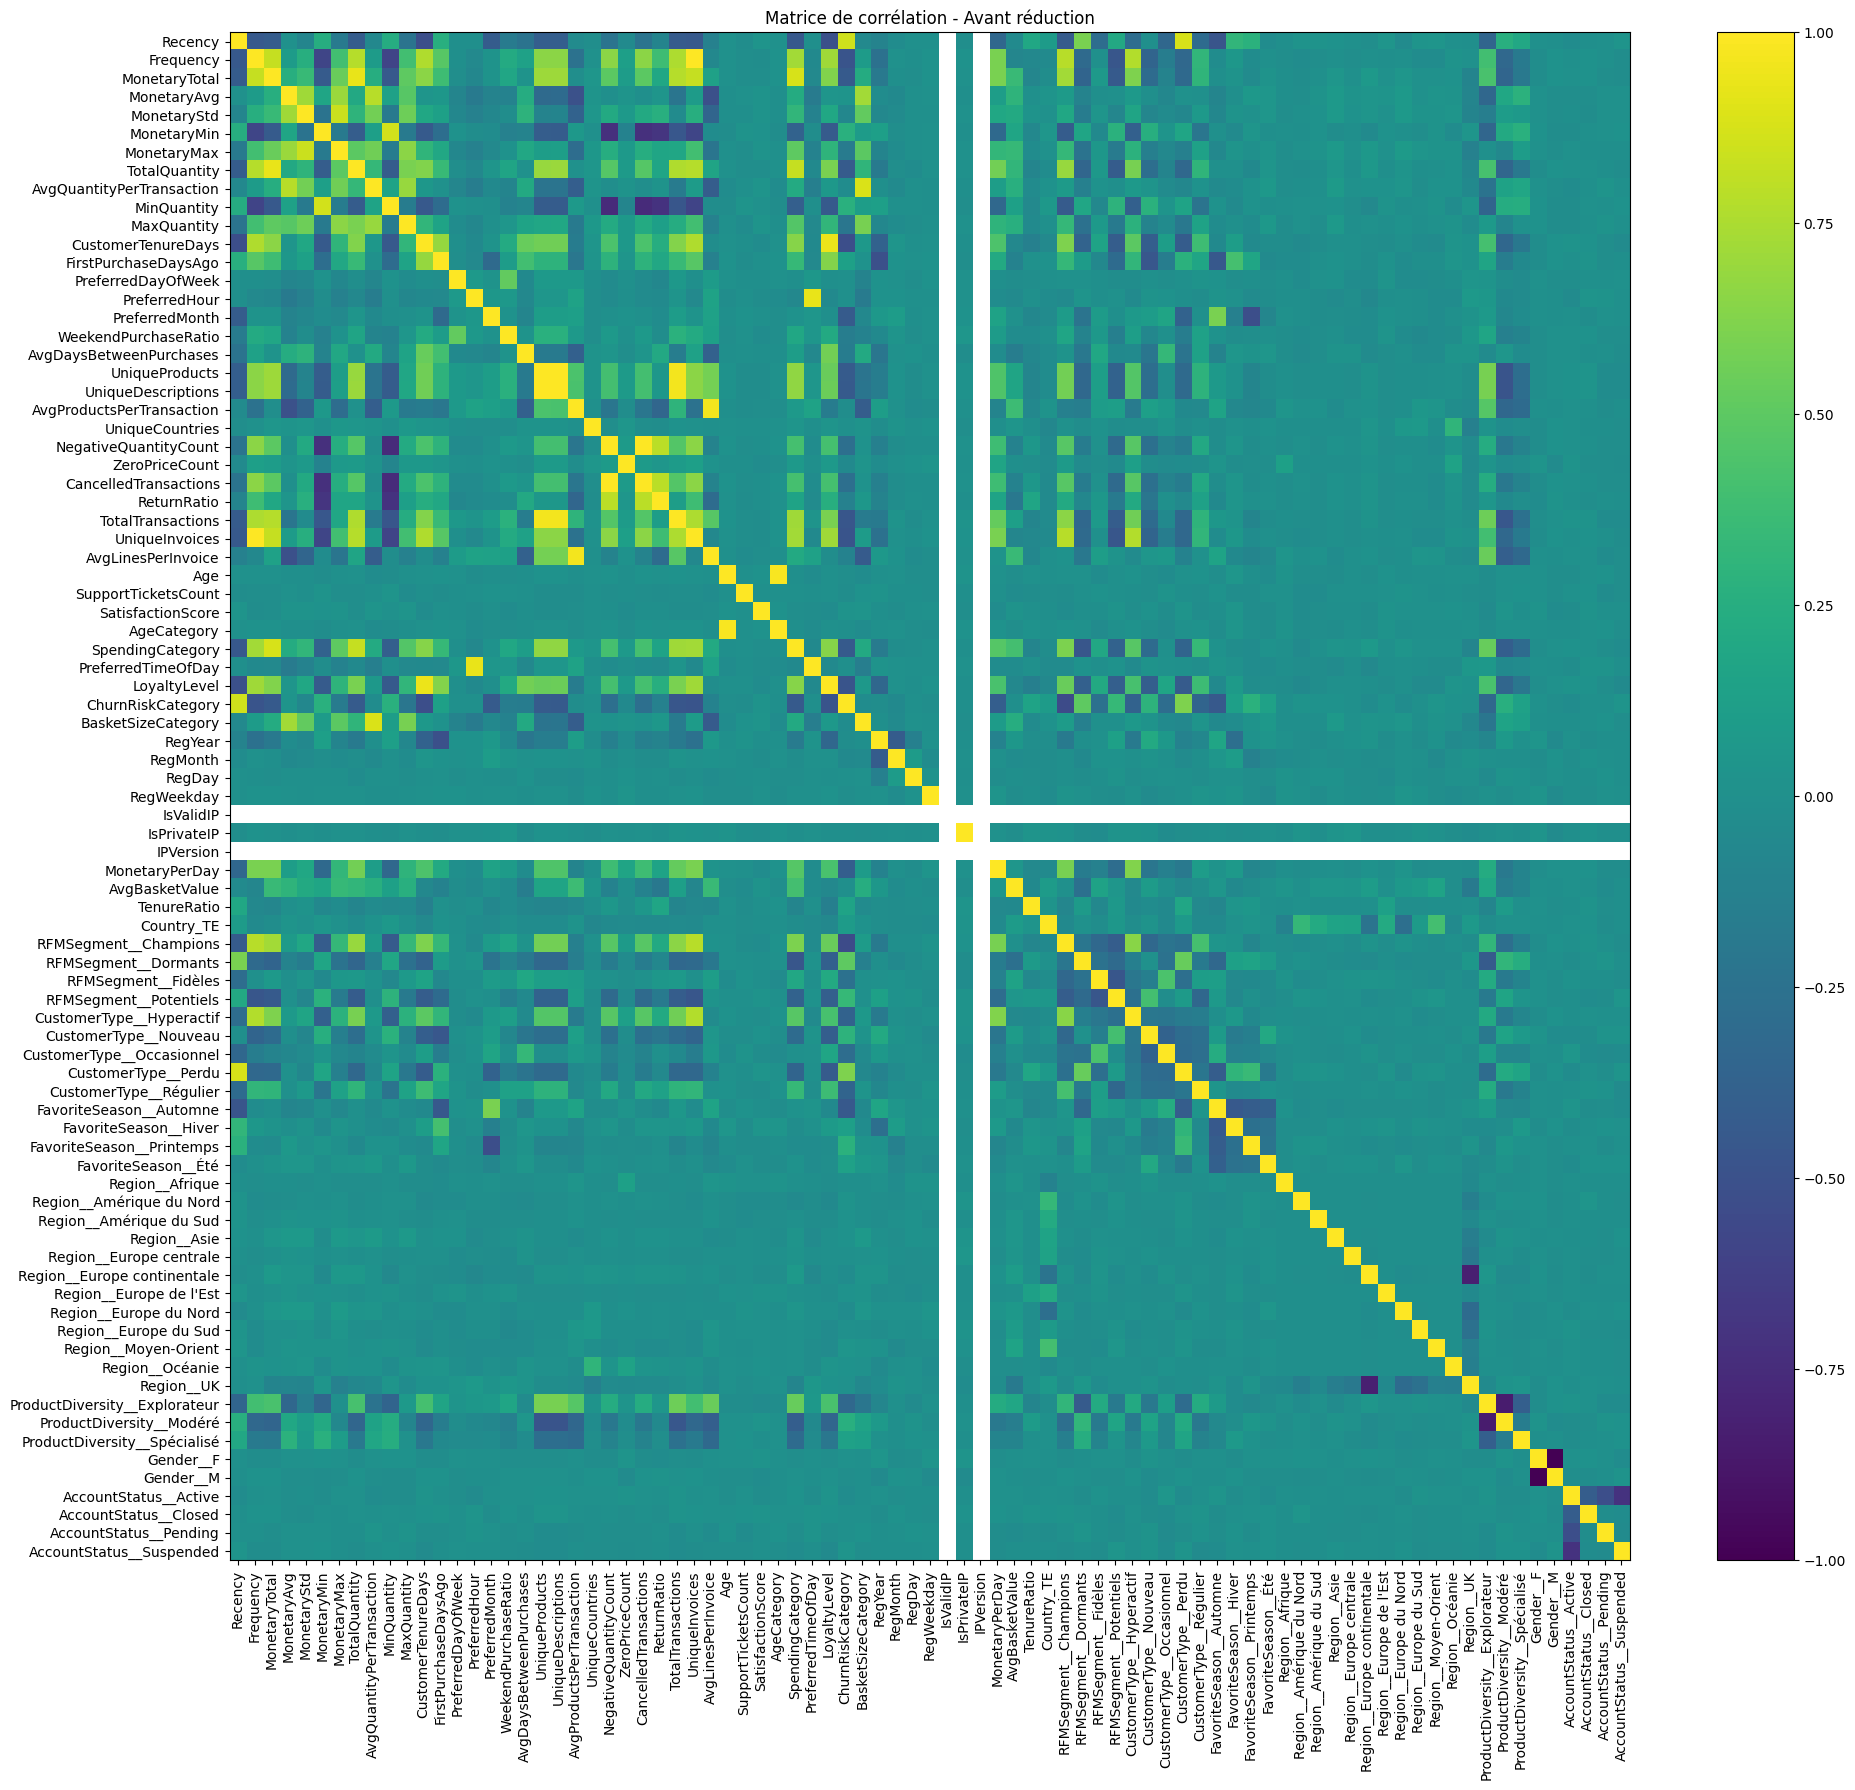

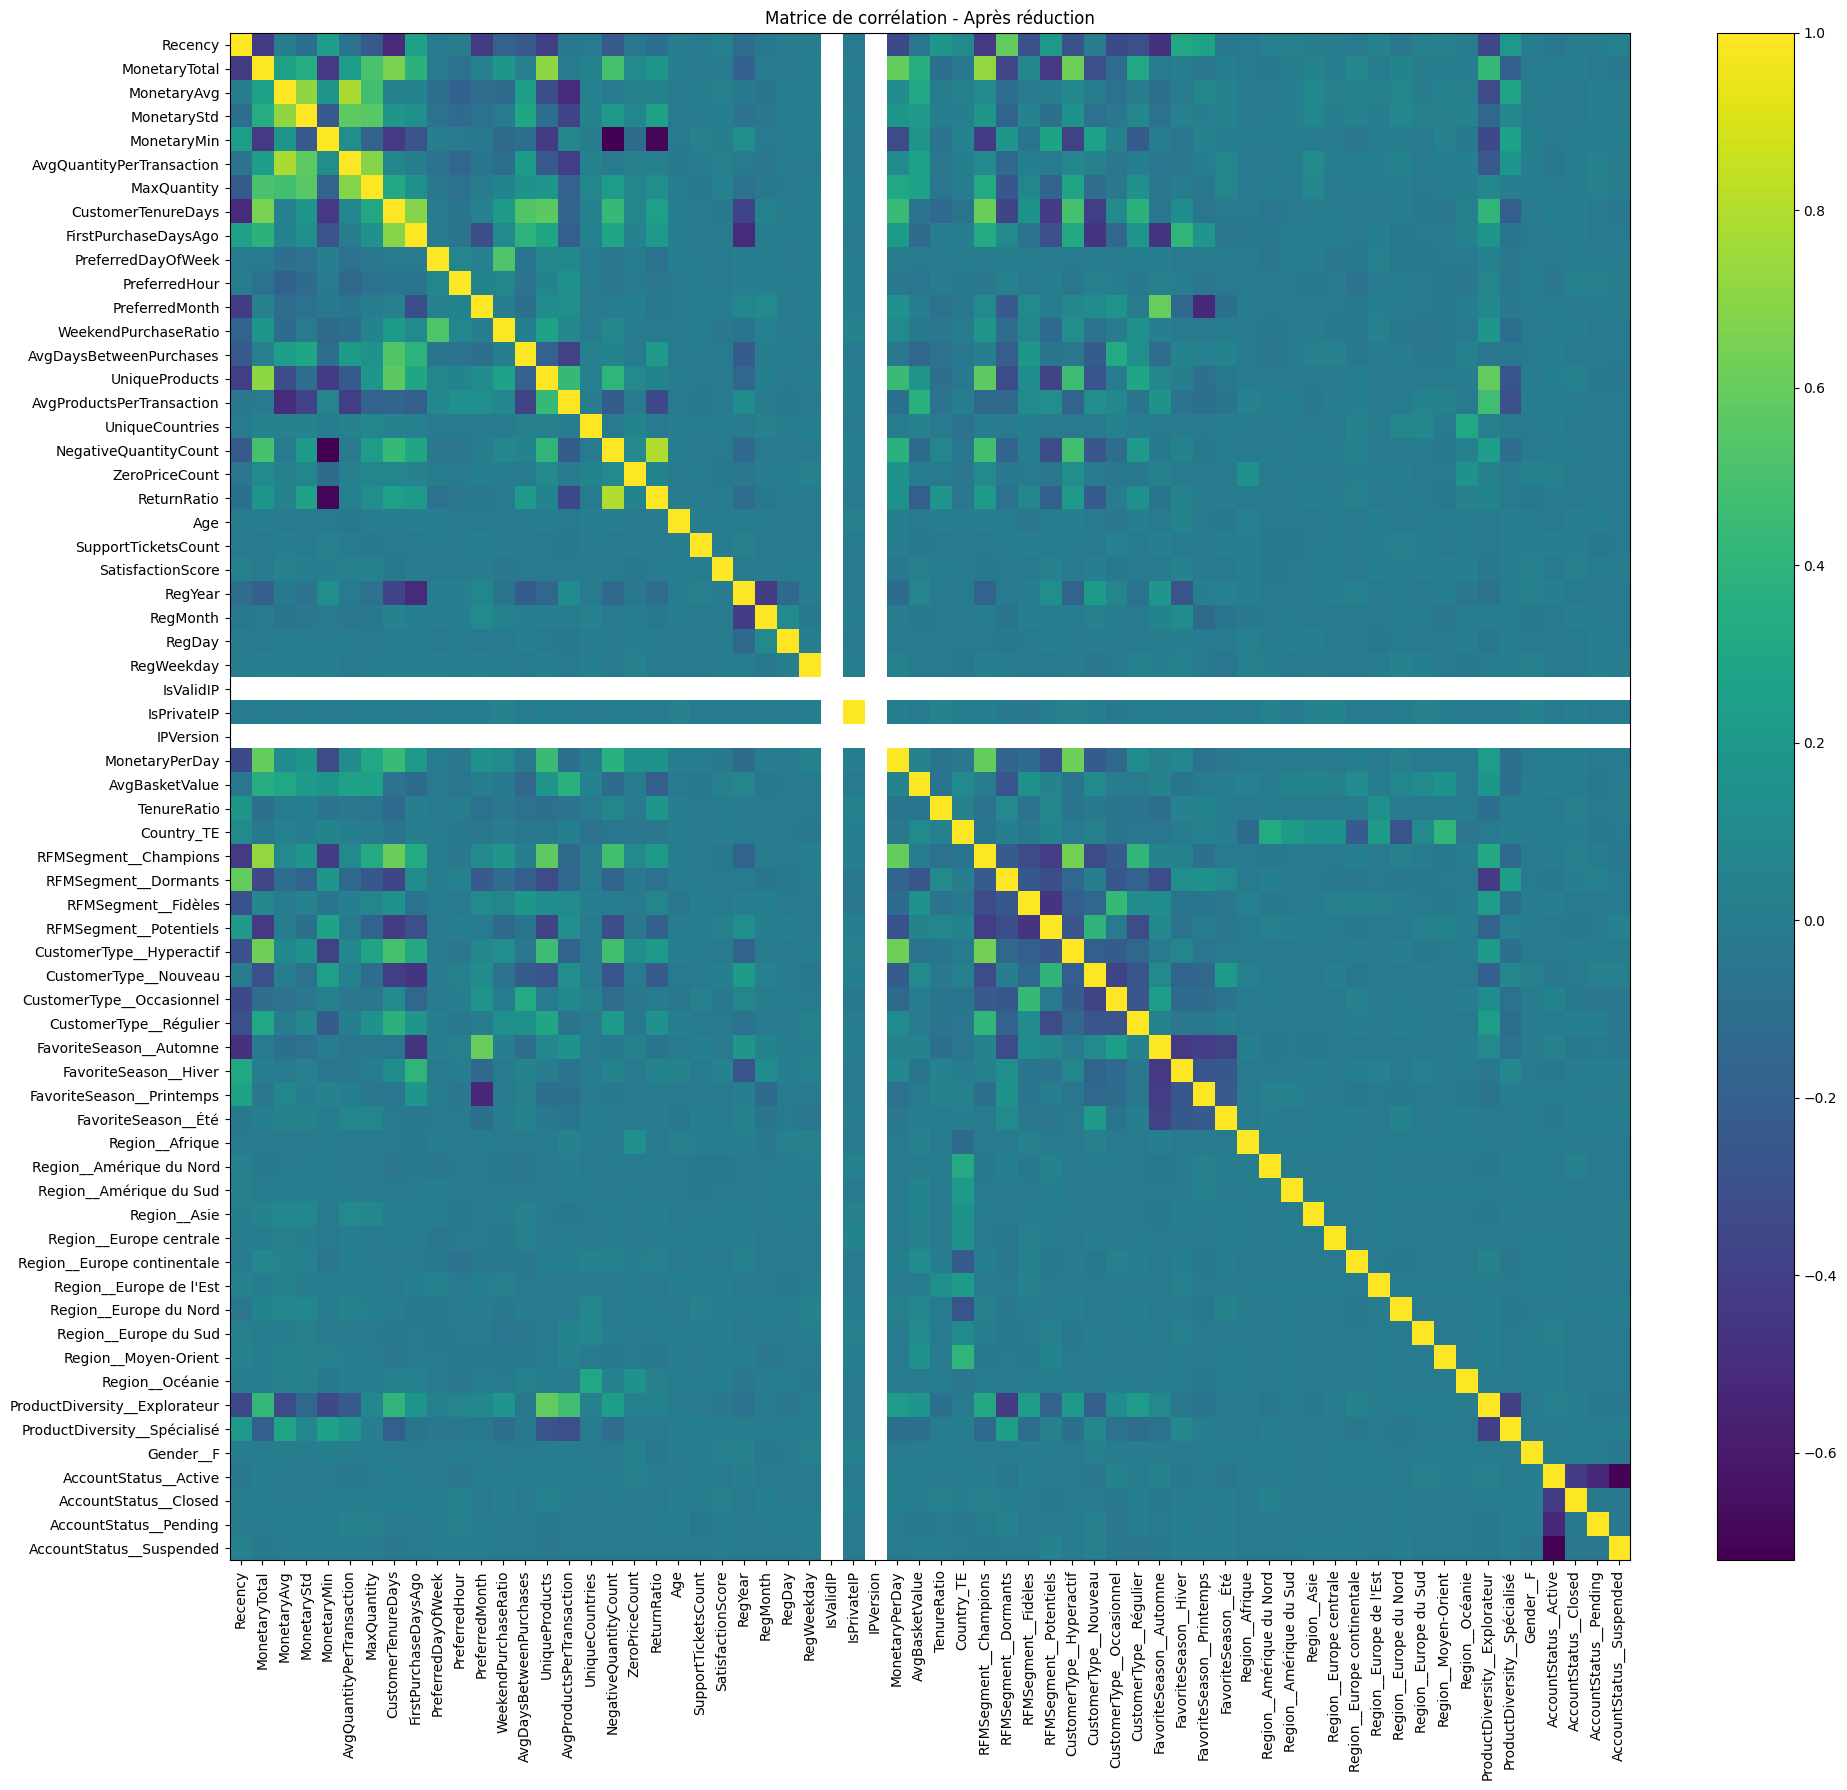

In [113]:
X_train_red = reducer.fit_transform(X_train_enc)
X_test_red = reducer.transform(X_test_enc)

In [114]:
reducer.summary()

Colonnes supprimées :
['AgeCategory', 'AvgLinesPerInvoice', 'BasketSizeCategory', 'CancelledTransactions', 'ChurnRiskCategory', 'CustomerType__Perdu', 'Frequency', 'Gender__M', 'LoyaltyLevel', 'MinQuantity', 'MonetaryMax', 'PreferredTimeOfDay', 'ProductDiversity__Modéré', 'Region__UK', 'SpendingCategory', 'TotalQuantity', 'TotalTransactions', 'UniqueDescriptions', 'UniqueInvoices']

Colonnes retenues :
['Recency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'AvgQuantityPerTransaction', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'Age', 'RegistrationDate', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'IsValidIP', 'IsPrivateIP', 'IPVersion', 'MonetaryPerDay', 'AvgBa

In [115]:
print(reducer.retained_columns_)

['Recency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'AvgQuantityPerTransaction', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'Age', 'RegistrationDate', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'IsValidIP', 'IsPrivateIP', 'IPVersion', 'MonetaryPerDay', 'AvgBasketValue', 'TenureRatio', 'Country_TE', 'RFMSegment__Champions', 'RFMSegment__Dormants', 'RFMSegment__Fidèles', 'RFMSegment__Potentiels', 'CustomerType__Hyperactif', 'CustomerType__Nouveau', 'CustomerType__Occasionnel', 'CustomerType__Régulier', 'FavoriteSeason__Automne', 'FavoriteSeason__Hiver', 'FavoriteSeason__Printemps', 'FavoriteSeason__Été', 'Region__Afrique', 'Region__Amérique du Nord', 'Region_

In [116]:
print(reducer.dropped_columns_)

['AgeCategory', 'AvgLinesPerInvoice', 'BasketSizeCategory', 'CancelledTransactions', 'ChurnRiskCategory', 'CustomerType__Perdu', 'Frequency', 'Gender__M', 'LoyaltyLevel', 'MinQuantity', 'MonetaryMax', 'PreferredTimeOfDay', 'ProductDiversity__Modéré', 'Region__UK', 'SpendingCategory', 'TotalQuantity', 'TotalTransactions', 'UniqueDescriptions', 'UniqueInvoices']


In [117]:
X_train_red = X_train_red.drop(columns=["RegistrationDate", "LastLoginIP"], errors="ignore")
X_test_red = X_test_red.drop(columns=["RegistrationDate", "LastLoginIP"], errors="ignore")

In [118]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


class FeatureScaler:
    def __init__(self, columns_to_scale=None):
        """
        columns_to_scale :
        - None  -> détection automatique des colonnes à scaler
        - liste -> colonnes explicitement fournies
        """
        self.columns_to_scale = columns_to_scale
        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    def _infer_columns_to_scale(self, X):
        """
        Détection automatique :
        - garde les colonnes numériques
        - exclut les colonnes one-hot (présence de '__')
        - exclut les colonnes IP dérivées
        - exclut les colonnes binaires 0/1
        """
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

        excluded_cols = {
            "IsValidIP",
            "IsPrivateIP",
            "IPVersion",
        }

        cols_to_scale = []

        for col in numeric_cols:
            # exclure one-hot
            if "__" in col:
                continue

            # exclure certaines colonnes discrètes/binaries IP
            if col in excluded_cols:
                continue

            s = pd.to_numeric(X[col], errors="coerce").dropna()

            # exclure binaire 0/1
            unique_vals = set(s.unique().tolist())
            if unique_vals.issubset({0, 1}):
                continue

            cols_to_scale.append(col)

        return cols_to_scale

    # ----------------------------------------------------------
    # FIT
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        if self.columns_to_scale is None:
            self.columns_to_scale_ = self._infer_columns_to_scale(X)
        else:
            self.columns_to_scale_ = [col for col in self.columns_to_scale if col in X.columns]

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.columns_to_scale_])

        self.output_columns_ = self.input_columns_.copy()
        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # TRANSFORM
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le FeatureScaler doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = X[self.input_columns_].copy()

        if self.columns_to_scale_:
            X[self.columns_to_scale_] = self.scaler_.transform(X[self.columns_to_scale_])

        return X

    # ----------------------------------------------------------
    # FIT_TRANSFORM
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

    # ----------------------------------------------------------
    # Résumé
    # ----------------------------------------------------------
    def summary(self):
        if not self.fitted_:
            raise RuntimeError("Le FeatureScaler doit être fit avant summary().")

        print("Colonnes scalées :")
        print(self.columns_to_scale_)

In [119]:
scaler = FeatureScaler()

X_train_scaled = scaler.fit_transform(X_train_red)
X_test_scaled = scaler.transform(X_test_red)

In [120]:
scaler.summary()

Colonnes scalées :
['Recency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'AvgQuantityPerTransaction', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'MonetaryPerDay', 'AvgBasketValue', 'TenureRatio', 'Country_TE']


In [121]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

X_train_scaled.head()

(3497, 64)
(875, 64)


,Recency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,AvgQuantityPerTransaction,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,...,Region__Europe du Sud,Region__Moyen-Orient,Region__Océanie,ProductDiversity__Explorateur,ProductDiversity__Spécialisé,Gender__F,AccountStatus__Active,AccountStatus__Closed,AccountStatus__Pending,AccountStatus__Suspended
380,-0.818469,-0.295711,-0.951437,-0.544192,0.251389,-0.955181,-0.668403,1.669033,1.195432,-1.367671,...,0,0,0,1,0,0,1,0,0,0
2472,1.368521,-0.916748,-0.038013,0.702621,0.352186,-0.815136,-0.763501,-1.006073,-0.002768,0.265780,...,0,0,0,0,1,0,0,0,0,1
1961,0.642931,-0.451056,0.204050,-0.722503,0.865062,-0.303919,-0.858599,-0.149438,0.360068,-0.278703,...,0,0,0,1,0,1,1,0,0,0
2029,-0.399467,1.067960,0.853677,0.167535,-0.074717,1.154115,2.184527,0.579453,0.317877,-0.823187,...,0,0,0,1,0,1,1,0,0,0
1384,-0.399467,0.432201,-0.406214,0.204845,0.215814,-0.489572,1.613941,0.940142,0.714465,-0.823187,...,0,0,0,1,0,1,1,0,0,0


In [122]:
from sklearn.decomposition import PCA


class PCAReducer:
    def __init__(self, n_components=None, explained_variance_threshold=None):
        """
        n_components :
            - int : nombre fixe de composantes
            - None : utilisé seulement si explained_variance_threshold est donné

        explained_variance_threshold :
            - float entre 0 et 1, ex: 0.95 pour garder 95% de variance
            - None si on veut imposer n_components
        """
        self.n_components = n_components
        self.explained_variance_threshold = explained_variance_threshold
        self.fitted_ = False

    # ----------------------------------------------------------
    # Outils
    # ----------------------------------------------------------
    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        raise TypeError("X doit être un DataFrame.")

    def _validate_input_columns(self, X):
        input_set = set(X.columns)
        train_set = set(self.input_columns_)

        missing_cols = [col for col in self.input_columns_ if col not in input_set]
        extra_cols = [col for col in X.columns if col not in train_set]

        if missing_cols or extra_cols:
            parts = []
            if missing_cols:
                parts.append(f"Colonnes manquantes : {missing_cols}")
            if extra_cols:
                parts.append(f"Colonnes supplémentaires : {extra_cols}")

            raise ValueError(
                "Les colonnes de X ne correspondent pas à celles vues au fit(). "
                + " | ".join(parts)
            )

    def _build_output_dataframe(self, X_pca, index):
        cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
        return pd.DataFrame(X_pca, columns=cols, index=index)

    # ----------------------------------------------------------
    # FIT
    # ----------------------------------------------------------
    def fit(self, X, y=None):
        X = self._to_dataframe(X)
        self.input_columns_ = X.columns.tolist()

        if self.explained_variance_threshold is not None:
            self.pca_ = PCA(n_components=self.explained_variance_threshold)
        else:
            self.pca_ = PCA(n_components=self.n_components)

        self.pca_.fit(X)

        self.n_components_selected_ = self.pca_.n_components_
        self.explained_variance_ratio_ = self.pca_.explained_variance_ratio_
        self.cumulative_explained_variance_ = np.cumsum(self.explained_variance_ratio_)

        self.output_columns_ = [f"PC{i+1}" for i in range(self.n_components_selected_)]
        self.fitted_ = True
        return self

    # ----------------------------------------------------------
    # TRANSFORM
    # ----------------------------------------------------------
    def transform(self, X):
        if not self.fitted_:
            raise RuntimeError("Le PCAReducer doit être fit avant transform.")

        X = self._to_dataframe(X)
        self._validate_input_columns(X)

        X = X[self.input_columns_].copy()
        X_pca = self.pca_.transform(X)

        return self._build_output_dataframe(X_pca, X.index)

    # ----------------------------------------------------------
    # FIT_TRANSFORM
    # ----------------------------------------------------------
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

    # ----------------------------------------------------------
    # Résumé
    # ----------------------------------------------------------
    def summary(self):
        if not self.fitted_:
            raise RuntimeError("Le PCAReducer doit être fit avant summary().")

        summary_df = pd.DataFrame({
            "Composante": self.output_columns_,
            "Variance expliquée": self.explained_variance_ratio_,
            "Variance cumulée": self.cumulative_explained_variance_
        })
        return summary_df

    # ----------------------------------------------------------
    # Visualisation
    # ----------------------------------------------------------
    def plot_explained_variance(self):
        if not self.fitted_:
            raise RuntimeError("Le PCAReducer doit être fit avant plot_explained_variance().")

        x = np.arange(1, len(self.explained_variance_ratio_) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(x, self.cumulative_explained_variance_, marker="o")
        plt.xticks(x)
        plt.xlabel("Nombre de composantes")
        plt.ylabel("Variance expliquée cumulée")
        plt.title("Variance expliquée cumulée par la PCA")
        plt.grid(True, alpha=0.3)
        plt.show()

In [123]:
pca_reducer = PCAReducer(n_components=None)

X_train_pca_full = pca_reducer.fit_transform(X_train_scaled)
X_test_pca_full = pca_reducer.transform(X_test_scaled)

In [124]:
pca_reducer.summary()

,Composante,Variance expliquée,Variance cumulée
0,PC1,1.525176e-01,0.152518
1,PC2,1.014089e-01,0.253927
2,PC3,7.504205e-02,0.328969
3,PC4,5.656278e-02,0.385531
4,PC5,4.942260e-02,0.434954
...,...,...,...
59,PC60,2.038352e-18,1.000000
60,PC61,1.379012e-18,1.000000
61,PC62,1.559703e-19,1.000000
62,PC63,0.000000e+00,1.000000


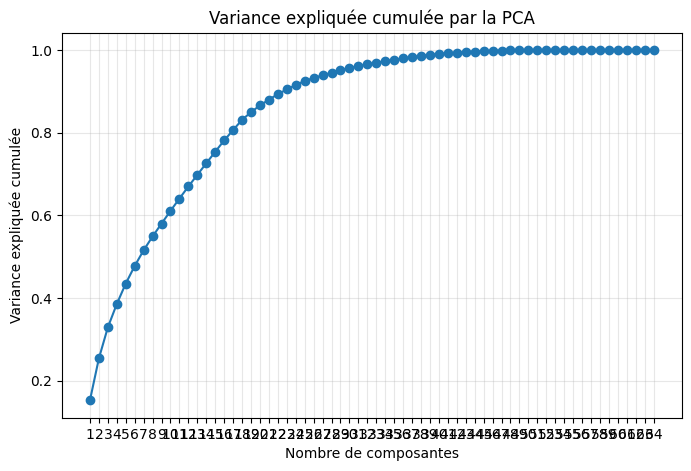

In [125]:
pca_reducer.plot_explained_variance()

In [126]:
thresholds = [0.80, 0.90, 0.95]

for t in thresholds:
    mask = pca_reducer.cumulative_explained_variance_ >= t
    
    if mask.any():
        n_comp = np.argmax(mask) + 1
        print(f"{int(t*100)}% atteint avec {n_comp} composantes")
    else:
        print(f"{int(t*100)}% non atteint")

80% atteint avec 17 composantes
90% atteint avec 23 composantes
95% atteint avec 29 composantes


In [127]:
pca_reducer = PCAReducer(n_components=17)

X_train_pca = pca_reducer.fit_transform(X_train_scaled)
X_test_pca = pca_reducer.transform(X_test_scaled)

In [128]:
print(X_train_pca.shape)
print(X_test_pca.shape)
pca_reducer.summary()

(3497, 17)
(875, 17)


,Composante,Variance expliquée,Variance cumulée
0,PC1,0.152518,0.152518
1,PC2,0.101409,0.253927
2,PC3,0.075042,0.328969
3,PC4,0.056563,0.385531
4,PC5,0.049423,0.434954
5,PC6,0.042642,0.477596
6,PC7,0.038003,0.515599
7,PC8,0.033539,0.549138
8,PC9,0.031071,0.580209
9,PC10,0.030735,0.610944


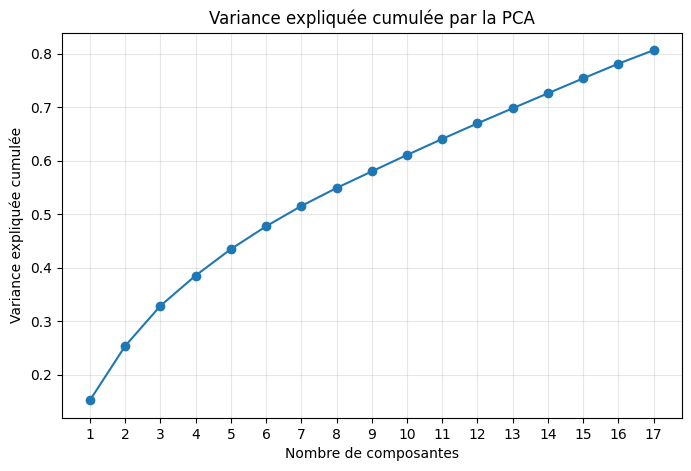

In [129]:
pca_reducer.plot_explained_variance()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
380,0.156355,-2.063665,0.007203,1.667427,1.355188,-2.525136,-0.473219,-1.298488,0.828191,0.270965,-0.299120,0.344783,-1.253798,-0.416124,0.274798,0.862380,0.596189
2472,-2.294857,0.982901,-1.571835,-0.078828,-0.629169,0.613021,0.009036,0.812308,-0.608242,-0.266442,-0.950906,0.692557,1.012002,0.662219,1.445610,-0.240627,-0.252348
1961,-1.629983,0.700122,-0.834219,0.817795,-0.086744,-0.121288,-1.320739,0.225879,-0.203397,1.196551,-1.006548,-0.578039,0.466294,1.300448,0.357223,-0.141543,0.037016
2029,1.875291,1.061207,1.261397,0.128367,0.053270,1.263211,-0.769127,0.316597,0.340010,-0.269018,1.294225,0.766404,0.188533,0.808656,0.564283,0.104752,0.294910
1384,0.769050,0.144279,0.383978,0.892202,-0.824379,-0.134158,-2.597575,0.744620,-0.171882,-1.644124,0.608474,-0.791389,0.304047,1.030164,-0.636856,-0.605467,0.222783


In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [132]:
print(X_train_pca.shape)
print(X_test_pca.shape)
print(y_train.shape)
print(y_test.shape)

(3497, 17)
(875, 17)
(3497,)
(875,)


In [133]:
# Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modèle de base
log_reg = LogisticRegression(random_state=42, max_iter=5000)

# Grille d'hyperparamètres
param_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }
]

# Plusieurs métriques
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",          # on choisit le meilleur modèle selon F1
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_pca, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\Lenovo\Desktop\projet_ml_retail\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Lenovo\Desktop\projet_ml_retail\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l2'], 'solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if N

In [134]:
print("Meilleurs hyperparamètres :")
print(grid_search.best_params_)

print("\nMeilleur score CV (F1) :")
print(grid_search.best_score_)

Meilleurs hyperparamètres :
{'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

Meilleur score CV (F1) :
0.9356509831088319


In [135]:
# Meilleur modèle
best_log_reg = grid_search.best_estimator_

# Prédictions sur test
y_pred = best_log_reg.predict(X_test_pca)

# Métriques
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

Accuracy : 0.9611428571428572
Precision: 0.9508771929824561
Recall   : 0.9312714776632303
F1-score : 0.9409722222222222


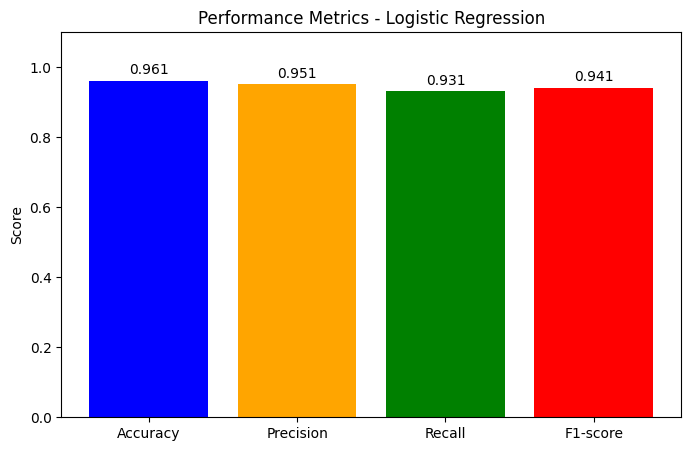

In [140]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metric_values = [acc, prec, rec, f1]
colors = ["blue", "orange", "green", "red"]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors)


for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Performance Metrics - Logistic Regression")
plt.show()

In [136]:
print("\nClassification report :")
print(classification_report(y_test, y_pred))


Classification report :
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       584
           1       0.95      0.93      0.94       291

    accuracy                           0.96       875
   macro avg       0.96      0.95      0.96       875
weighted avg       0.96      0.96      0.96       875



In [137]:
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred))

Confusion matrix :
[[570  14]
 [ 20 271]]


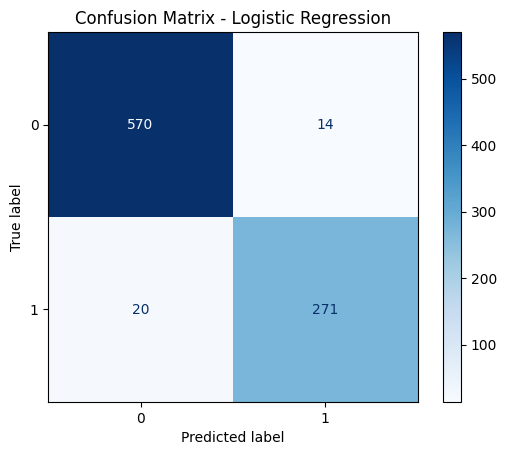

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions
y_pred = best_log_reg.predict(X_test_pca)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [141]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [142]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model = SVC(random_state=42)

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10],
        "class_weight": [None, "balanced"]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto", 0.01, 0.1],
        "class_weight": [None, "balanced"]
    }
]

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train_pca, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-

In [143]:
print("Meilleurs hyperparamètres :")
print(grid_search_svm.best_params_)

print("\nMeilleur score CV (F1) :")
print(grid_search_svm.best_score_)

Meilleurs hyperparamètres :
{'C': 10, 'class_weight': None, 'gamma': 0.01, 'kernel': 'rbf'}

Meilleur score CV (F1) :
0.9600266186442639


In [144]:
best_svm = grid_search_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_pca)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-score :", f1_svm)

Accuracy : 0.9748571428571429
Precision: 0.9786476868327402
Recall   : 0.9450171821305842
F1-score : 0.9615384615384616


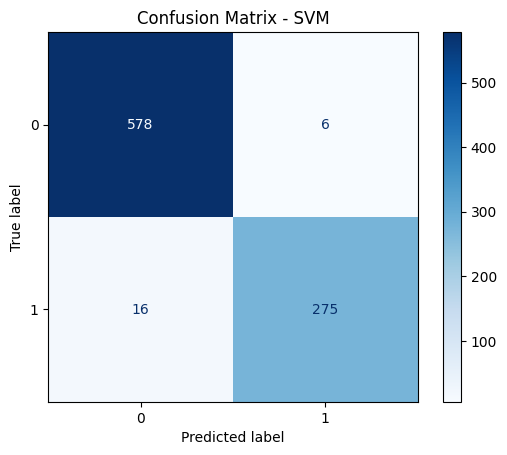

In [145]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - SVM")
plt.show()

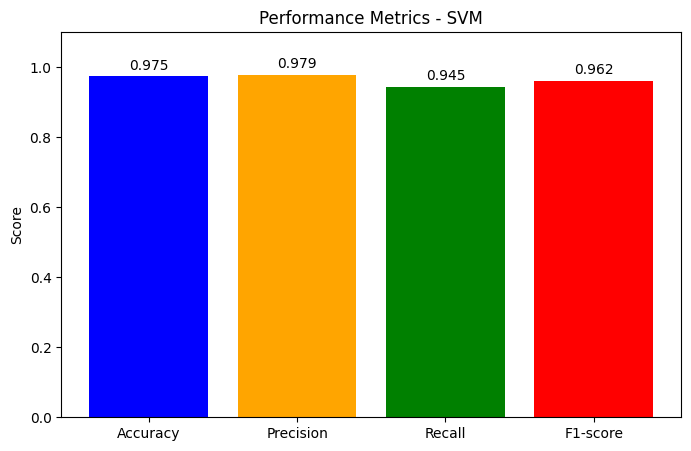

In [146]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metric_values = [acc_svm, prec_svm, rec_svm, f1_svm]
colors = ["blue", "orange", "green", "red"]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Performance Metrics - SVM")
plt.show()

In [147]:
from sklearn.ensemble import RandomForestClassifier

In [148]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_pca, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbo

In [149]:
print("Meilleurs hyperparamètres :")
print(grid_search_rf.best_params_)

print("\nMeilleur score CV (F1) :")
print(grid_search_rf.best_score_)

Meilleurs hyperparamètres :
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Meilleur score CV (F1) :
0.8971925885823924


In [150]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_pca)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1-score :", f1_rf)

Accuracy : 0.9451428571428572
Precision: 0.9727626459143969
Recall   : 0.8591065292096219
F1-score : 0.9124087591240876


In [151]:
print("\nClassification report :")
print(classification_report(y_test, y_pred_rf))


Classification report :
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       584
           1       0.97      0.86      0.91       291

    accuracy                           0.95       875
   macro avg       0.95      0.92      0.94       875
weighted avg       0.95      0.95      0.94       875



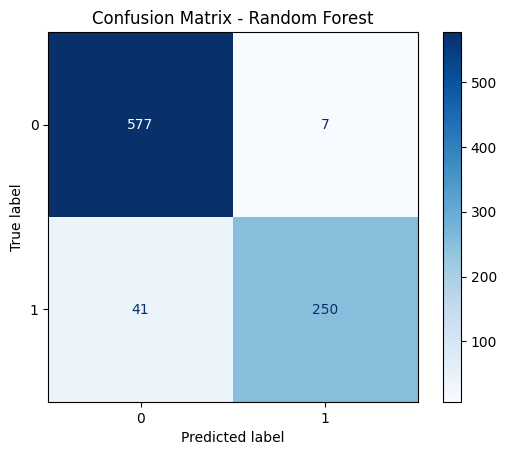

In [152]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

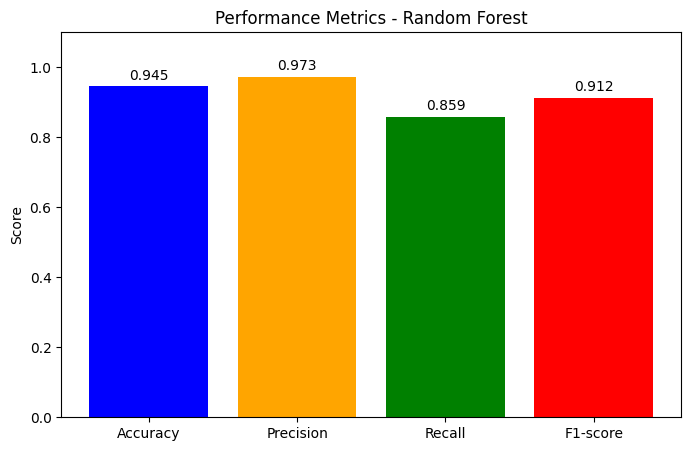

In [153]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metric_values = [acc_rf, prec_rf, rec_rf, f1_rf]
colors = ["blue", "orange", "green", "red"]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Performance Metrics - Random Forest")
plt.show()

In [154]:
import joblib
joblib.dump(best_svm, "../models/best_svm_model_01NB.joblib")

['../models/best_svm_model_01NB.joblib']